# Titanic Exercise

to install seaborn :
```bash
conda install -c conda-forge seaborn
````


In [10]:
import pandas as pd
from seaborn import load_dataset
import matplotlib.pyplot as plt
import numpy as np

In [11]:
embarked_labels = {
  "C": "Cherbourg",
  "Q": "Queenstown",
  "S": "Southampton",
}

In [15]:
# 1. Load the dataset
titanic: pd.DataFrame = load_dataset("titanic")
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [16]:
titanic.info()
titanic.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [17]:
# 2. Data cleaning
# 2.1. Check the missing values
print(titanic.shape)
print(titanic.isnull().sum())

# 2.2. Replace the missing values in age with the mean
titanic.fillna({"age": titanic["age"].mean()}, inplace=True)

# 2.3 delete empty embarked rows
titanic.dropna(subset=["embarked"], inplace=True)

# 2.4 delete deck column
titanic.pop("deck")

# 2.5 drop duplicate columns
titanic.drop(columns=["class", "who", "alive"], inplace=True)

titanic

(891, 15)
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,embark_town,alone
0,0,3,male,22.000000,1,0,7.2500,S,True,Southampton,False
1,1,1,female,38.000000,1,0,71.2833,C,False,Cherbourg,False
2,1,3,female,26.000000,0,0,7.9250,S,False,Southampton,True
3,1,1,female,35.000000,1,0,53.1000,S,False,Southampton,False
4,0,3,male,35.000000,0,0,8.0500,S,True,Southampton,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,True,Southampton,True
887,1,1,female,19.000000,0,0,30.0000,S,False,Southampton,True
888,0,3,female,29.699118,1,2,23.4500,S,False,Southampton,False
889,1,1,male,26.000000,0,0,30.0000,C,True,Cherbourg,True


In [18]:
print(titanic.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
adult_male     0
embark_town    0
alone          0
dtype: int64


In [37]:
# 3 Analyse data
# 3.1 Calculer le taux global de survie des passagers du Titanic.
survival_rate = titanic.loc[titanic.survived == 1].survived.sum() / titanic.shape[0] * 100
survival_rate = titanic.survived.mean() * 100
survival_rate = titanic.survived.value_counts(normalize=True).loc[1]
survival_rate = titanic.groupby("survived").size() / titanic.shape[0]
survival_rate

survived
0    0.617548
1    0.382452
dtype: float64

In [107]:
# 3.2 Analyser la répartition des passagers par classe (Pclass) et par port d'embarquement (Embarked)
passenger_class_embarked = titanic.groupby(["pclass", "embarked"]).survived.count().unstack()
passenger_class_embarked

embarked,C,Q,S
pclass,,,
1,85,2,127
2,17,3,164
3,66,72,353


In [55]:
# 3.3 Calculer la proportion de passagers masculins et féminins.
gender_proportion = titanic.sex.value_counts(normalize=True)
gender_proportion

sex
male      0.649044
female    0.350956
Name: proportion, dtype: float64

<Axes: xlabel='age'>

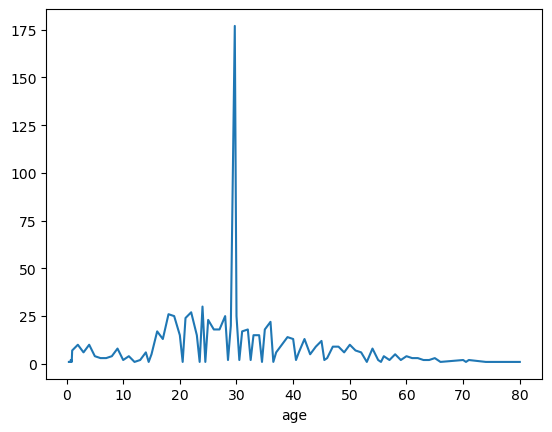

In [58]:
# 3.4 Identifier la distribution d'âge des passagers et trouver les catégories d'âge les plus représentées.
age_distribution = titanic.age.value_counts()
age_distribution.sort_index().plot()

In [ ]:
bins = [0, 2, 12, 18, 30, 50, 70, 100]
labels = ["baby", "child", "teen", "young_adult", "adult", "senior", "senior++"]

cutted_age = pd.cut(titanic.age, bins=bins, labels=labels)
titanic["age_category"] = cutted_age

titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,embark_town,alone,age_category
0,0,3,male,22.000000,1,0,7.2500,S,True,Southampton,False,young_adult
1,1,1,female,38.000000,1,0,71.2833,C,False,Cherbourg,False,adult
2,1,3,female,26.000000,0,0,7.9250,S,False,Southampton,True,young_adult
3,1,1,female,35.000000,1,0,53.1000,S,False,Southampton,False,adult
4,0,3,male,35.000000,0,0,8.0500,S,True,Southampton,True,adult
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,True,Southampton,True,young_adult
887,1,1,female,19.000000,0,0,30.0000,S,False,Southampton,True,young_adult
888,0,3,female,29.699118,1,2,23.4500,S,False,Southampton,False,young_adult
889,1,1,male,26.000000,0,0,30.0000,C,True,Cherbourg,True,young_adult


<Axes: xlabel='age_category'>

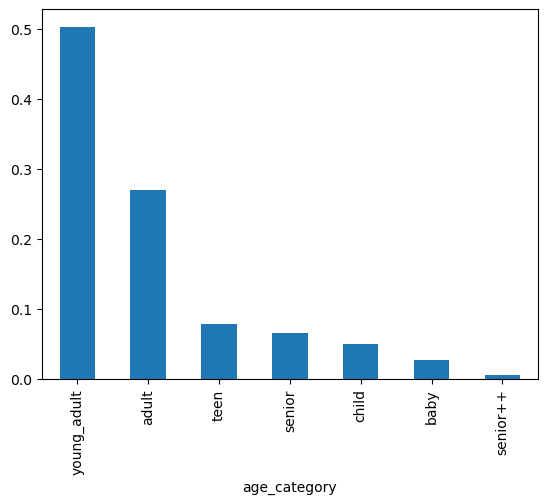

In [64]:
titanic.age_category.value_counts(normalize=True).plot(kind="bar")

In [71]:
# 4 Alives analyse
# 4.1 Analyser la survie en fonction de la classe des billets (Pclass).

class_survived = pd.crosstab(titanic.pclass, titanic.survived, normalize="index")
class_survived

survived,0,1
pclass,,
1,0.373832,0.626168
2,0.527174,0.472826
3,0.757637,0.242363


<Axes: xlabel='pclass'>

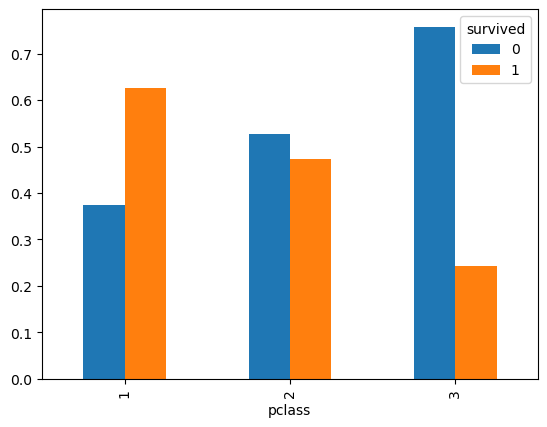

In [79]:
class_survived = titanic.groupby("pclass").survived.value_counts(normalize=True)
class_survived.unstack().plot(kind="bar")

In [83]:
# 4.2 Examiner la survie en fonction du genre (Sex) des passagers.
gender_survival = titanic.groupby("sex").survived.value_counts(normalize=True).unstack()
gender_survival

survived,0,1
sex,,
female,0.259615,0.740385
male,0.811092,0.188908


array([<Axes: ylabel='0'>, <Axes: ylabel='1'>], dtype=object)

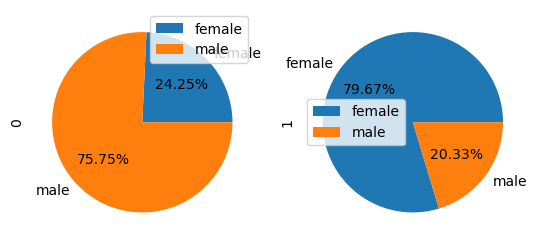

In [84]:
gender_survival.plot(kind="pie", subplots=True, autopct="%.2f%%")

In [89]:
class_sex_survival = titanic.groupby(["pclass", "sex"]).survived\
.value_counts(normalize=True).unstack()

class_sex_survival

survived              0         1
pclass sex                       
1      female  0.032609  0.967391
       male    0.631148  0.368852
2      female  0.078947  0.921053
       male    0.842593  0.157407
3      female  0.500000  0.500000
       male    0.864553  0.135447

<Axes: xlabel='pclass,sex'>

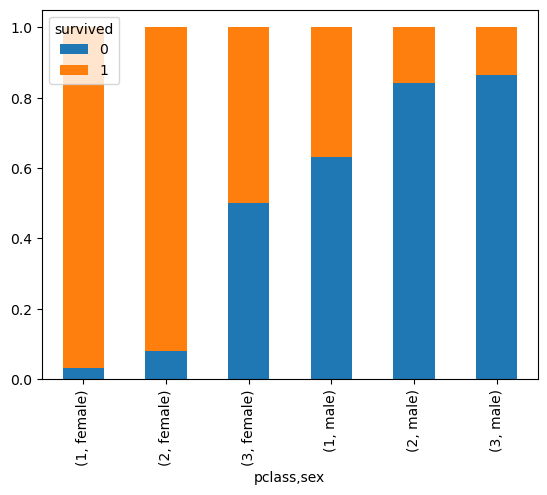

In [95]:
class_sex_survival.sort_index(level=[1], ascending=True)\
.plot(kind="bar", stacked=True)


/var/folders/9m/mdxclk9x25z0_ny0wr9rt4n80000gn/T/ipykernel_13735/3938656785.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby("age_category").survived.value_counts(normalize=True).unstack().plot.bar(stacked=True)


<Axes: xlabel='age_category'>

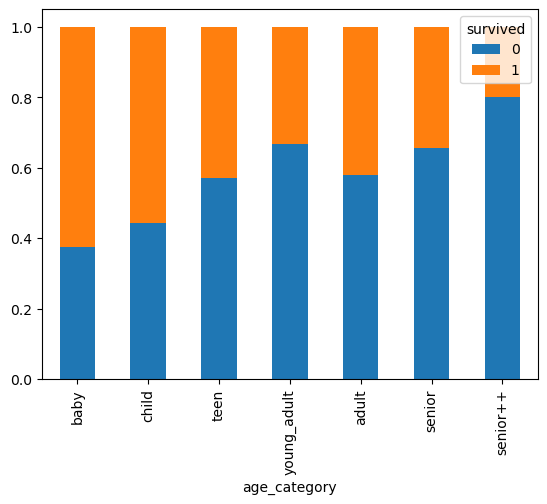

In [98]:
# 4.3 Étudier la survie en fonction de l'âge (Age) des passagers.
titanic.groupby("age_category").survived.value_counts(normalize=True).unstack().plot.bar(stacked=True)

In [101]:
# 4.4 Analyser la survie en fonction du port d'embarquement (Embarked).
titanic.groupby("embarked").survived.value_counts(normalize=True).unstack()

survived,0,1
embarked,,
C,0.446429,0.553571
Q,0.610390,0.389610
S,0.663043,0.336957


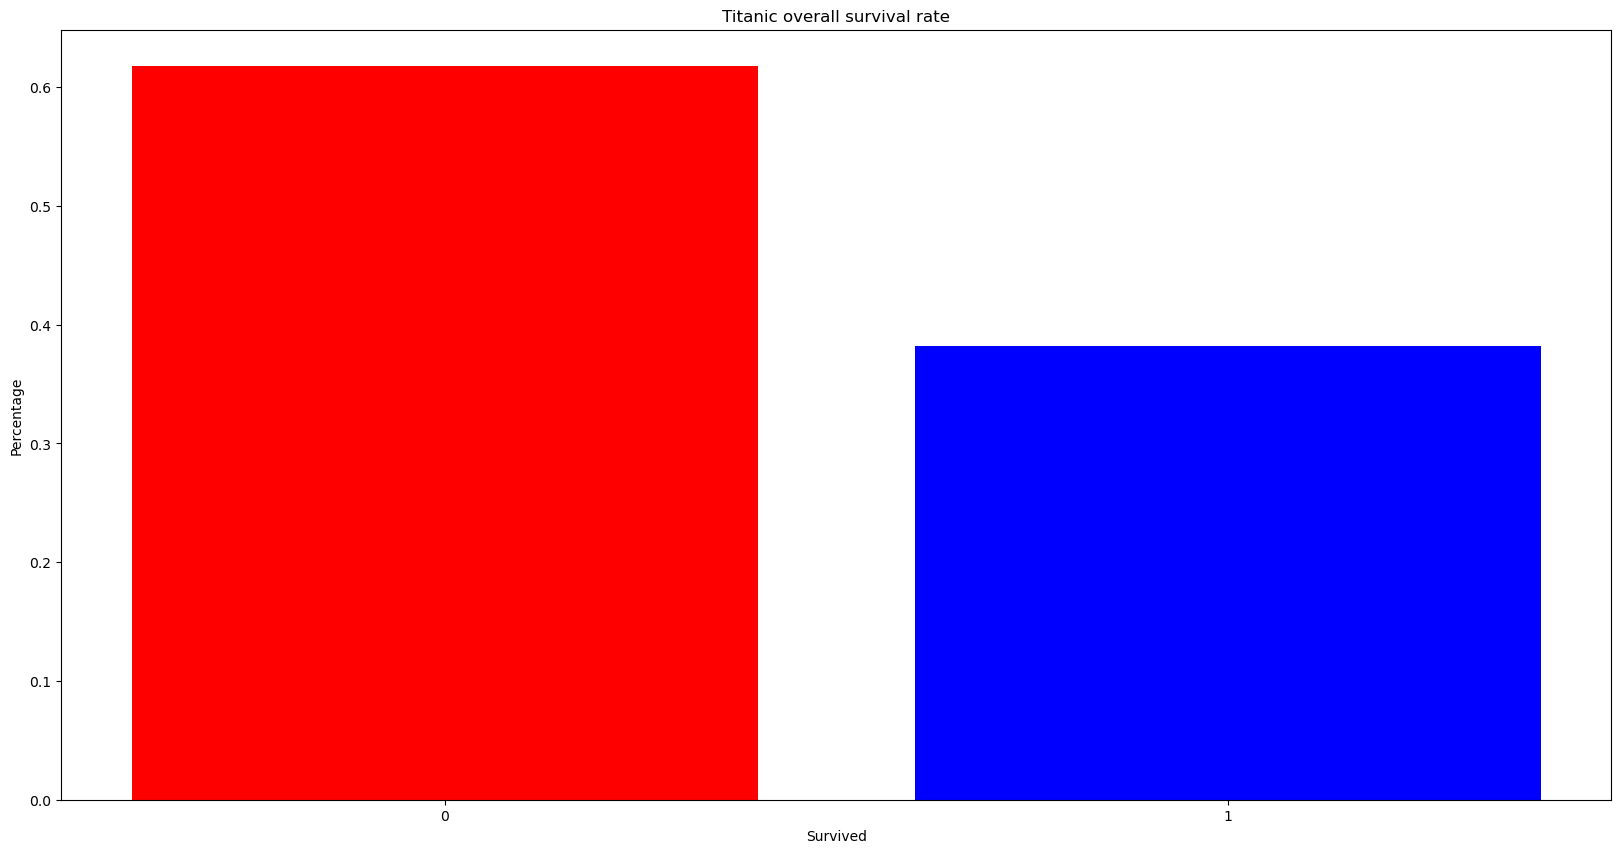

<Axes: title={'center': 'Titanic overall survival rate'}, xlabel='survived', ylabel='Percentage'>

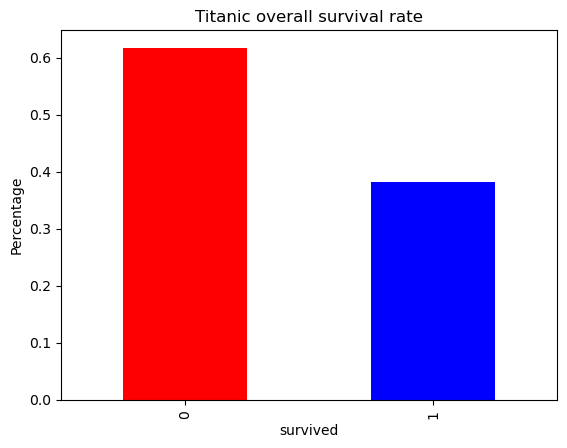

In [134]:
# 5 Plottings
# 5.1 Créer un diagramme à barres (plt.bar) pour visualiser le taux de survie global.
plt.figure(figsize=(20, 10))
plt.bar(survival_rate.index.astype(str), survival_rate.values, color=["#ff0000", "blue"])
plt.xlabel("Survived")
plt.ylabel("Percentage")
plt.title("Titanic overall survival rate")

plt.show()

survival_rate.plot.bar(
  color=["red", "blue"], 
  title="Titanic overall survival rate", 
  ylabel="Percentage"
)

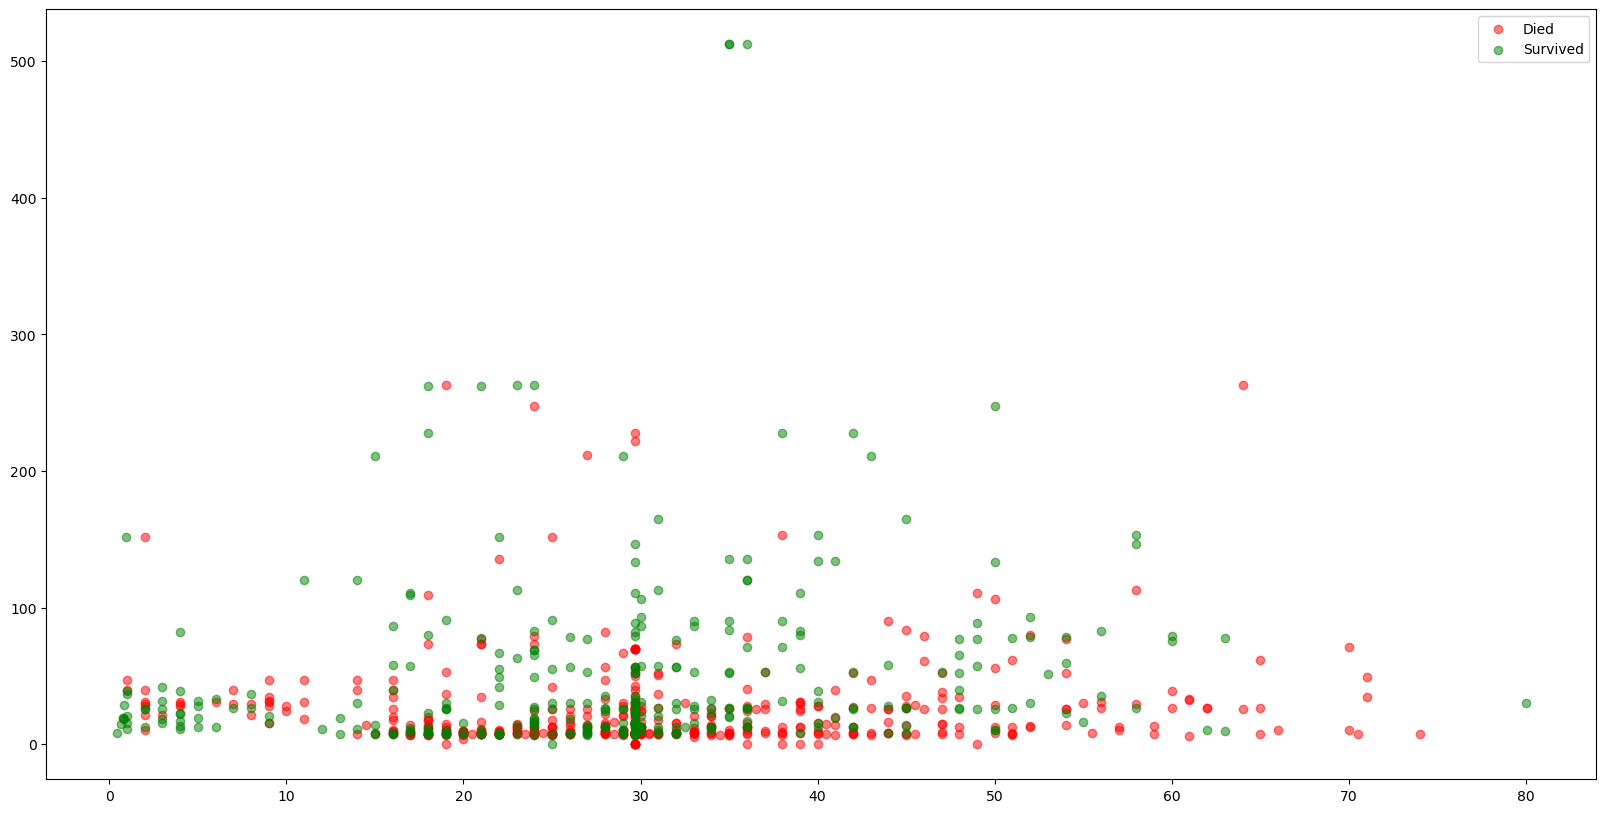

In [ ]:
# 5.2 Créer un nuage de points (plt.scatter) pour représenter la relation entre l'âge (Age) et le prix du billet (Fare) en fonction de la survie.
survived_passengers = titanic.loc[titanic.survived == 1]
died_passengers = titanic.loc[titanic.survived == 0]

plt.figure(figsize=(20, 10))

plt.scatter(
  died_passengers.age,
  died_passengers.fare,
  c="r", alpha=0.5, label="Died"
)
plt.scatter(
  survived_passengers.age,
  survived_passengers.fare,
  c="g", alpha=0.5, label="Survived"
)

plt.legend()

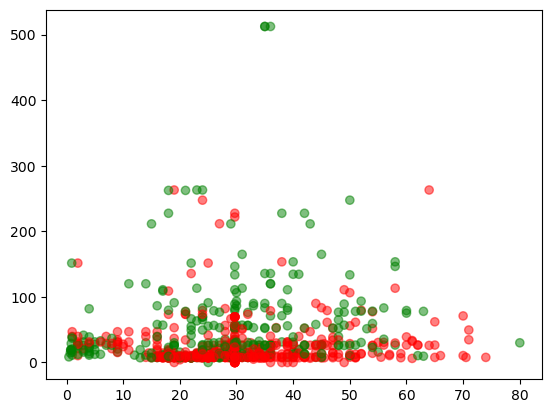

In [147]:
plt.scatter(
  titanic.age, 
  titanic.fare, 
  color=titanic.survived.map(lambda s: "r" if s == 0 else "g"),
  alpha=0.5
)

([<matplotlib.patches.Wedge at 0x31382cbb0>,
 [Text(-0.49644333452149636, 0.9816027789330968, 'male'),
  Text(0.49644318630359463, -0.9816028538939435, 'female')],
 [Text(-0.2707872733753616, 0.5354196975998708, '64.90%'),
  Text(0.2707871925292334, -0.5354197384876055, '35.10%')])

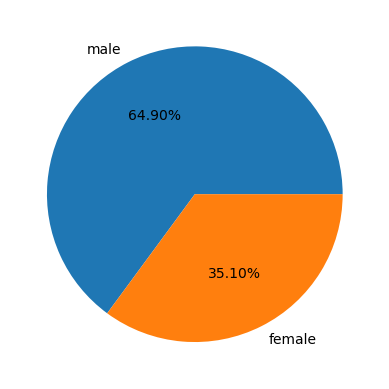

In [ ]:
# 5.3 Produire un diagramme circulaire (Pie chart) pour montrer la proportion de passagers masculins et féminins.
plt.pie(gender_proportion, labels=gender_proportion.index, autopct="%.2f%%")

pclass,1,2,3
embarked,,,
Q,0.025974,0.038961,0.935065
C,0.505952,0.101190,0.392857
S,0.197205,0.254658,0.548137


<Axes: xlabel='embarked'>

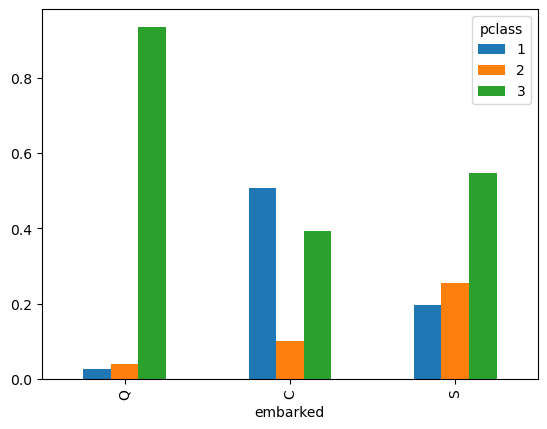

In [ ]:
# 5.4 Générer un graphique en barres (plt.bar) pour montrer la répartition des passagers par classe (Pclass) et par port d'embarquement (Embarked)
embarked_class = titanic.groupby("embarked").pclass\
  .value_counts(normalize=True).unstack()\
  .loc[["Q", "C", "S"], :]

display(embarked_class)
embarked_class.plot.bar()

,age,fare,pclass,sibsp,parch,survived,gender
age,1.000000,0.088604,-0.327954,-0.231875,-0.178232,-0.074673,-0.089434
fare,0.088604,1.000000,-0.548193,0.160887,0.217532,0.255290,0.179958
pclass,-0.327954,-0.548193,1.000000,0.081656,0.016824,-0.335549,-0.127741
sibsp,-0.231875,0.160887,0.081656,1.000000,0.414542,-0.034040,0.116348
parch,-0.178232,0.217532,0.016824,0.414542,1.000000,0.083151,0.247508
survived,-0.074673,0.255290,-0.335549,-0.034040,0.083151,1.000000,0.541585
gender,-0.089434,0.179958,-0.127741,0.116348,0.247508,0.541585,1.000000


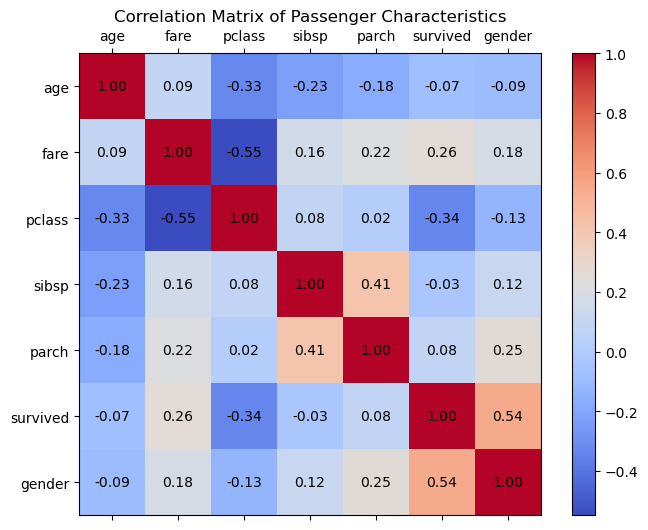

In [173]:
# 6 Bonus for the datascients experts ;P
# 6.1 Examiner la corrélation entre les différentes caractéristiques des passagers pour identifier les relations significatives.

correlation_columns = ["age", "fare", "pclass", "sibsp", "parch", "survived", "gender"]
titanic["gender"] = titanic.sex.map({"male": 0, "female": 1})

correlation_matrix = titanic.loc[:, correlation_columns].corr()
display(correlation_matrix)


# Create a basic heatmap using Matplotlib
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(correlation_matrix, cmap='coolwarm')
fig.colorbar(cax)

# Set labels
ax.set_xticks(np.arange(len(correlation_columns)))
ax.set_yticks(np.arange(len(correlation_columns)))
ax.set_xticklabels(correlation_columns)
ax.set_yticklabels(correlation_columns)

# Display the correlation values
for i in range(len(correlation_columns)):
  for j in range(len(correlation_columns)):
    text = ax.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}', ha='center', va='center', color='black')

# Set title
plt.title('Correlation Matrix of Passenger Characteristics')

# Show the plot
plt.show()

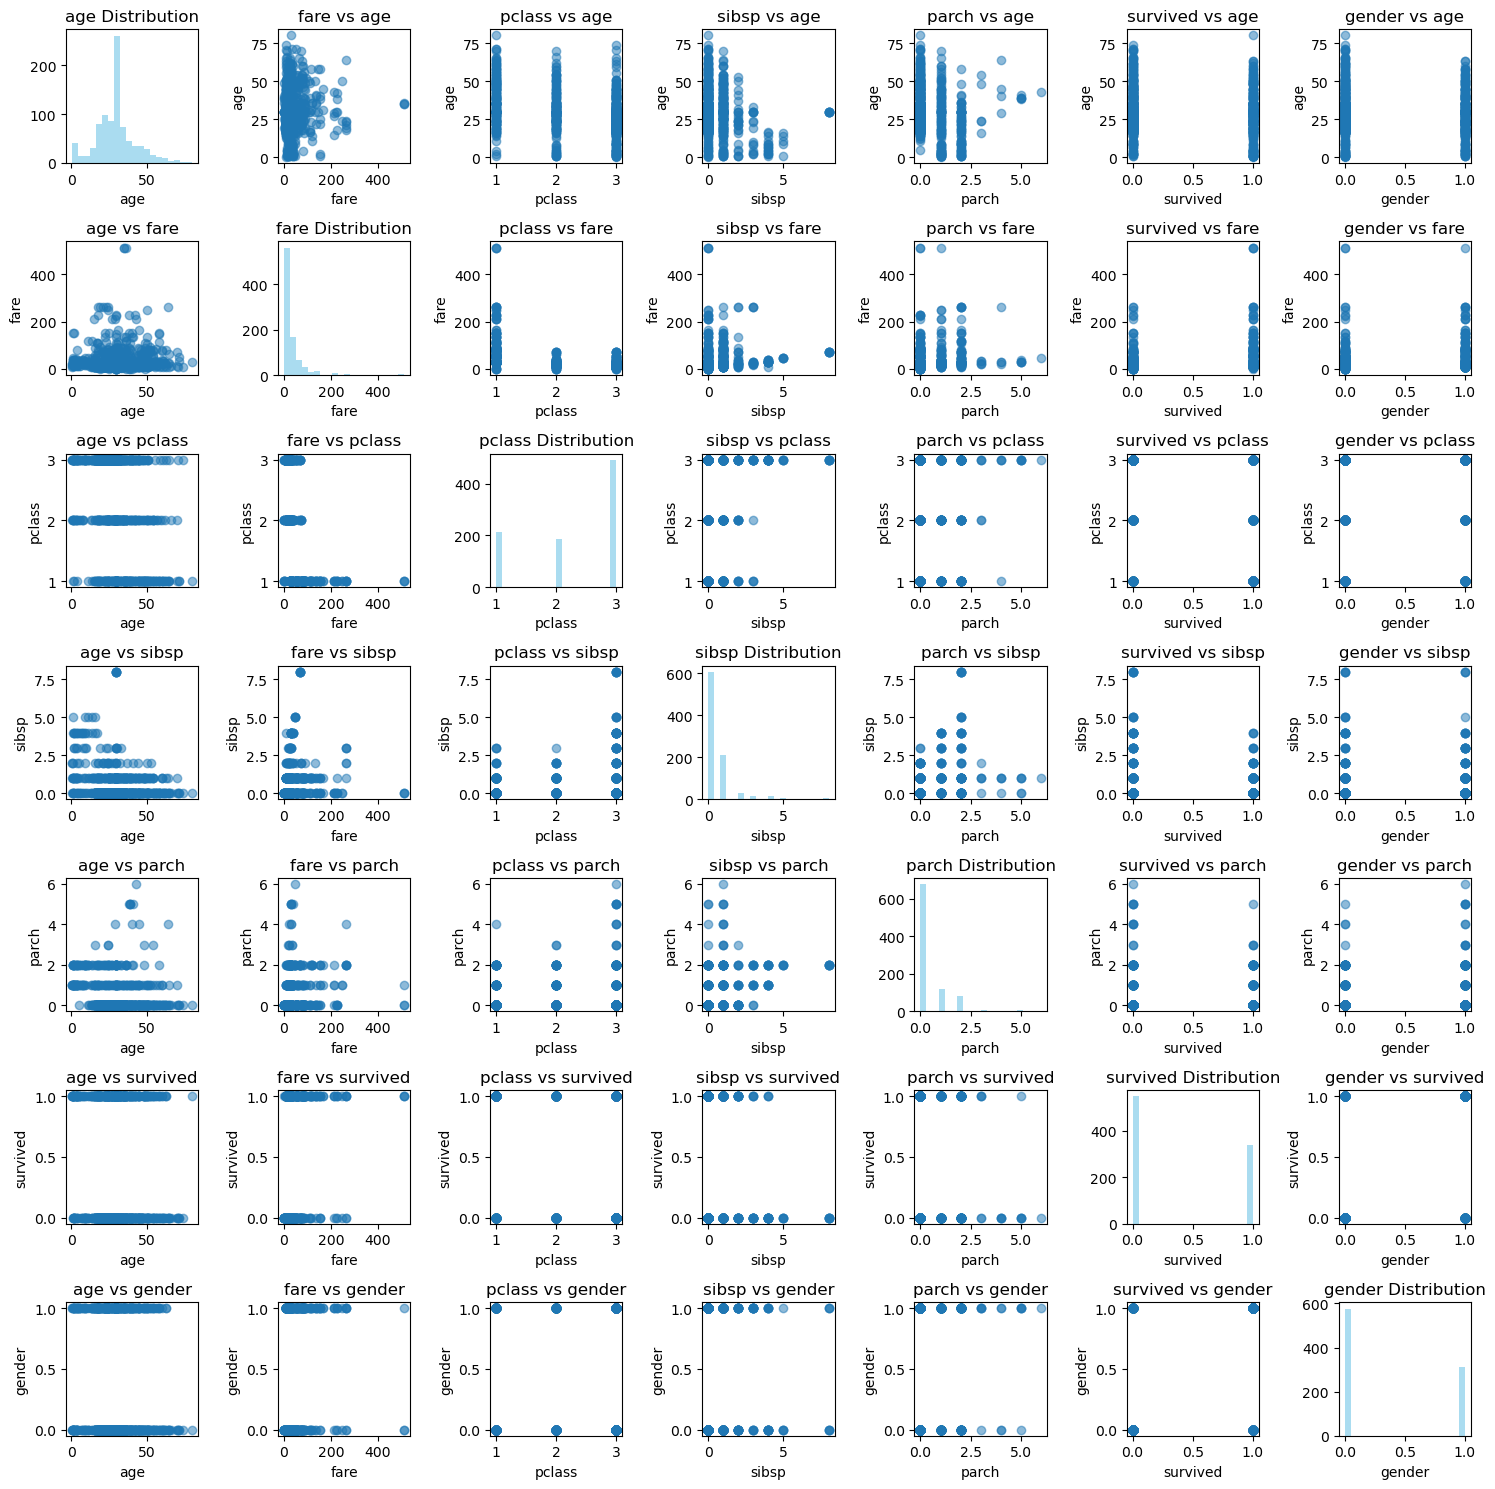

In [176]:
# 6.2 Effectuer une analyse plus approfondie en créant des graphiques supplémentaires pour mettre en évidence des tendances ou des insights intéressants.

import numpy as np

# Select relevant numerical columns
numerical_columns = ['age', 'fare', 'pclass', 'sibsp', 'parch', 'survived', 'gender']

# Create a matrix of scatter plots
fig, axes = plt.subplots(nrows=len(numerical_columns), ncols=len(numerical_columns), figsize=(15, 15))

for i in range(len(numerical_columns)):
    for j in range(len(numerical_columns)):
        if i == j:
            axes[i, j].hist(titanic[numerical_columns[i]], bins=20, color='skyblue', alpha=0.7)
            axes[i, j].set_title(f'{numerical_columns[i]} Distribution')
            axes[i, j].set_xlabel(numerical_columns[i])
        else:
            axes[i, j].scatter(titanic[numerical_columns[j]], titanic[numerical_columns[i]], alpha=0.5)
            axes[i, j].set_title(f'{numerical_columns[j]} vs {numerical_columns[i]}')
            axes[i, j].set_xlabel(numerical_columns[j])
            axes[i, j].set_ylabel(numerical_columns[i])
            # a, b = np.polyfit(titanic[numerical_columns[j]], titanic[numerical_columns[i]], 1)
            # axes[i, j].plot(titanic[numerical_columns[j]], a*titanic[numerical_columns[j]]+b, c="r")
            # a, b = np.polyfit(titanic[numerical_columns[i]], titanic[numerical_columns[j]], 1)
            # axes[i, j].plot(titanic[numerical_columns[i]], a*titanic[numerical_columns[i]]+b, c="g")

# Adjust layout
plt.tight_layout()
plt.show()